<a href="https://colab.research.google.com/github/kmyers111/ML-Models/blob/main/unsupervised/second_cgan_assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
tf.__version__


'2.19.0'

In [2]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

In [3]:
from google.colab import files
uploaded = files.upload()


Saving train.tar.gz to train.tar.gz


In [4]:
!tar -xvzf train.tar.gz

Streaming output truncated to the last 5000 lines.
train/10099.png
train/10088.png
train/10017.png
train/9983.png
train/9849.png
train/9845.png
train/9810.png
train/9737.png
train/9732.png
train/9727.png
train/9725.png
train/9590.png
train/18326.png
train/18324.png
train/18300.png
train/18207.png
train/18201.png
train/18191.png
train/18159.png
train/18141.png
train/18129.png
train/18118.png
train/18056.png
train/18034.png
train/18023.png
train/17970.png
train/17952.png
train/17937.png
train/17870.png
train/17859.png
train/17830.png
train/17699.png
train/17662.png
train/17600.png
train/17599.png
train/17576.png
train/17546.png
train/17542.png
train/17541.png
train/17532.png
train/17511.png
train/17499.png
train/17465.png
train/17464.png
train/17424.png
train/17413.png
train/17397.png
train/17217.png
train/17209.png
train/17167.png
train/17151.png
train/17145.png
train/17085.png
train/17081.png
train/17057.png
train/17039.png
train/17019.png
train/16994.png
train/16940.png
train/16903.pn

In [5]:
!tar -xvzf test.tar.gz

tar (child): test.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now


In [46]:
IMG_SIZE = (32, 32)
BATCH_SIZE = 256

BUFFER_SIZE = 60000

#Loads the data
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/train",
    label_mode=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

# Normalize the images to [-1, 1]
def normalize(images):
    images = tf.cast(images, tf.float32)
    return (images - 127.5) / 127.5

train_dataset = train_dataset.map(normalize)

# Batch and shuffle the data
train_dataset = train_dataset.shuffle(BUFFER_SIZE).prefetch(tf.data.AUTOTUNE)

Found 33402 files.


In [47]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))
    assert model.output_shape == (None, 8, 8, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 8, 8, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2),
                                     padding='same',
                                     use_bias=False,
                                     activation='tanh'))

    #model.add(layers.Flatten())
    #model.add(layers.Dense(1))
   # model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    #assert model.output_shape == (None, 32, 32, 3)

    return model

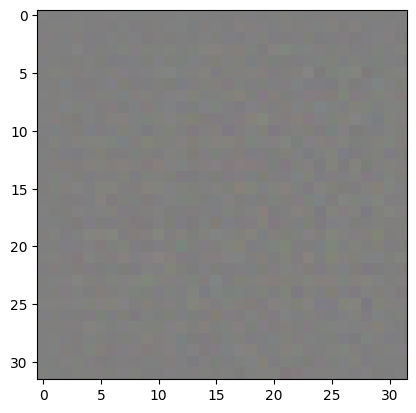

In [48]:
noise_dim = 100
generator = make_generator_model()

noise = tf.random.normal([1, noise_dim])
generated_image = generator(noise, training=False)
img = (generated_image[0] + 1) / 2

plt.imshow(img)

In [49]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[32, 32, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [50]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image, training=False)
print (decision)

tf.Tensor([[-0.00364396]], shape=(1, 1), dtype=float32)


In [51]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [52]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [53]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [54]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

In [55]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [56]:
EPOCHS = 200
noise_dim = 100
num_examples_to_generate = 16

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [57]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [58]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    # Produce images for the GIF as you go
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)

    # Save the model every 15 epochs
    if (epoch + 1) % 15 == 0:
      checkpoint.save(file_prefix = checkpoint_prefix)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

In [59]:
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow((predictions[i] + 1) / 2)
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

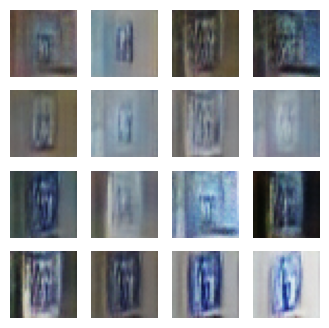

In [60]:
train(train_dataset, EPOCHS)

In [61]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))